In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

In [2]:
GROUP1 = pd.read_csv("../data/FOOD-DATA-GROUP1.csv")
GROUP2 = pd.read_csv("../data/FOOD-DATA-GROUP2.csv")
GROUP3 = pd.read_csv("../data/FOOD-DATA-GROUP3.csv")
GROUP4 = pd.read_csv("../data/FOOD-DATA-GROUP4.csv")
GROUP5 = pd.read_csv("../data/FOOD-DATA-GROUP5.csv")

In [3]:
data = pd.concat([
    GROUP1,
     GROUP2,
     GROUP3,
     GROUP4,
     GROUP5
])

data.reset_index(
    drop=True,
    inplace=True
)

In [4]:
print(data.shape)

data.head()

(2395, 37)


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [5]:
print(data.isnull().sum())

Unnamed: 0.1            0
Unnamed: 0              0
food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Vitamin B11             0
Vitamin B12             0
Vitamin B2              0
Vitamin B3              0
Vitamin B5              0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Copper                  0
Iron                    0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Nutrition Density       0
dtype: int64


In [6]:
numeric_columns = [
    "Caloric Value",
    "Fat",
    "Carbohydrates",
    "Sugars",
    "Protein",
    "Dietary Fiber",
    "Nutrition Density"
]

In [7]:
for col in numeric_columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

In [8]:
data = data.fillna(0)

In [9]:
data["Target"] = (
    (data["Sugars"] <= 20) &
    (data["Fat"] <= 20)
).astype(int)

In [10]:
print(
    data["Target"].value_counts()
)

Target
1    1999
0     396
Name: count, dtype: int64


In [11]:
features = [
    "Caloric Value",
    "Fat",
    "Carbohydrates",
    "Sugars",
    "Protein",
    "Dietary Fiber",
    "Nutrition Density"
]

X = data[features]

y = data["Target"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred = rf_model.predict(
    X_test_scaled
)

In [16]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Random Forest Accuracy:",
    accuracy
)

Random Forest Accuracy: 1.0


In [17]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00       417

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479



In [18]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[ 62   0]
 [  0 417]]


In [19]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
1                Fat    0.398721
3             Sugars    0.268313
0      Caloric Value    0.181621
6  Nutrition Density    0.051018
4            Protein    0.044794
2      Carbohydrates    0.044482
5      Dietary Fiber    0.011050


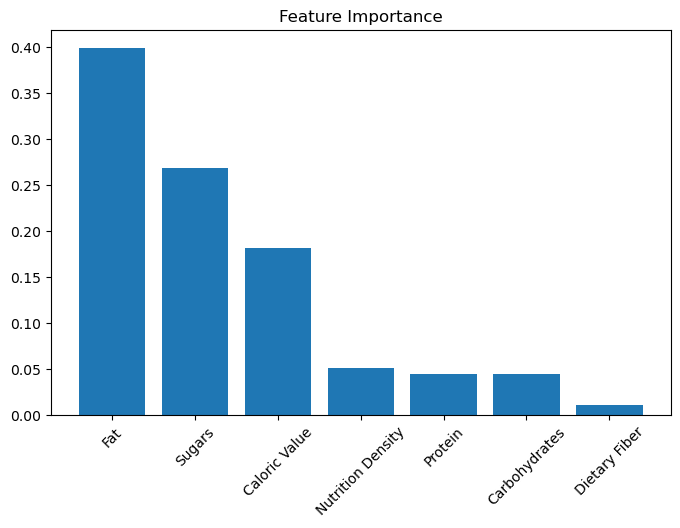

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [21]:
import pickle

pickle.dump(
    rf_model,
    open("random_forest_model.pkl", "wb")
)